# Pauli Frame Correction Comparison Study

This notebook compares the MBQC translation of a Google 12-qubit supremacy circuit
in two configurations:

- **Corrected**: the standard MBQC implementation with feed-forward Pauli
  corrections applied (`apply_pauli_corrections=True`).
- **Uncorrected**: same parity measurements, but no compensating X/Z byproducts
  applied (`apply_pauli_corrections=False`). Each trajectory's output state
  is therefore a different Pauli-conjugated version of the ideal state.

The comparison answers a specific question: is the uncorrected output just "more
randomness" (uniform over bitstrings), or does it retain structure that
looks like a Pauli-twirled version of the ideal distribution? The metrics
distinguish these:

- **Statevector fidelity** with Google's amplitude target (corrected case only;
  meaningless per-trajectory when uncorrected).
- **XEB** of the (averaged) output distribution against Google's `p_ideal`.
- **TVD** of the (averaged) output distribution against Google's `p_ideal`
  *and* against the uniform distribution.
- **Bitstring-level plots** showing how each bitstring's probability shifts.

## 1. Imports and configuration

In [5]:
import os
import sys
import importlib.util
from collections import OrderedDict

import numpy as np
import matplotlib.pyplot as plt
import cirq

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.compiler import transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

# This notebook lives in notebooks/; repo root is one level up.
REPO_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '..'))
TETRON_DIR = os.path.join(REPO_ROOT, 'src', 'tetron')
GOOGLE_DIR = os.path.join(REPO_ROOT, 'google_supremacy_circuit_files')

if TETRON_DIR not in sys.path:
    sys.path.insert(0, TETRON_DIR)

from qubit_mapping import (
    grid_to_qiskit_index,
    grid_to_sq_ancilla_index,
    grid_edge_to_qiskit_indices,
    GRID_TO_LOGICAL,
)
from mbqc_translated_gates import MBQCTranslatedGates

print('Imports OK.')

Imports OK.


In [6]:
print(os.path.isdir(GOOGLE_DIR))
print(os.path.isdir(DATA_DIR))
print(os.listdir(os.path.join(REPO_ROOT, 'data')))

True
False
['google_amplitudes', 'google_measurement_bitstrings']


## 2. Load Google circuit and amplitude files

In [7]:
CIRCUIT_BASENAME   = 'circuit_n12_m14_s0_e0_pEFGH.py'
AMPLITUDE_BASENAME = 'amplitudes_n12_m14_s0_e0_pEFGH.txt'

DATA_DIR = os.path.join(REPO_ROOT, 'data', 'google_amplitudes')


def resolve_input_file(basename):
    for path in [os.path.join(GOOGLE_DIR, basename),
                 os.path.join(DATA_DIR, basename),
                 os.path.join(REPO_ROOT, basename)]:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(basename)


CIRCUIT_FILE   = resolve_input_file(CIRCUIT_BASENAME)
AMPLITUDE_FILE = resolve_input_file(AMPLITUDE_BASENAME)


def load_cirq_circuit(path):
    spec = importlib.util.spec_from_file_location('google_circuit', path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod.QUBIT_ORDER, mod.CIRCUIT


QUBIT_ORDER, CIRCUIT = load_cirq_circuit(CIRCUIT_FILE)
N_LOGICAL = len(QUBIT_ORDER)
DIM       = 2 ** N_LOGICAL

print(f'Circuit:    {CIRCUIT_FILE}')
print(f'Amplitudes: {AMPLITUDE_FILE}')
print(f'Qubits:     {N_LOGICAL}')
print(f'Moments:    {len(CIRCUIT)}')

Circuit:    C:\Users\Chris\Repositories\mbqc-circuit-comparison\google_supremacy_circuit_files\circuit_n12_m14_s0_e0_pEFGH.py
Amplitudes: C:\Users\Chris\Repositories\mbqc-circuit-comparison\data\google_amplitudes\amplitudes_n12_m14_s0_e0_pEFGH.txt
Qubits:     12
Moments:    57


## 3. Build Google's amplitude target

Same loader as the main comparison notebook; reverses the bitstring to match
Qiskit's qubit-0-is-LSB convention.

In [8]:
def load_google_amplitude_target(path, n_qubits, normalize=True):
    dim = 2 ** n_qubits
    amps = OrderedDict()
    with open(path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 3:
                continue
            bs, re_s, im_s = parts
            if len(bs) != n_qubits or any(c not in '01' for c in bs):
                continue
            amp = complex(float(re_s), float(im_s))
            if bs not in amps:
                amps[bs] = amp

    vec = np.zeros(dim, dtype=complex)
    for bs, amp in amps.items():
        idx = int(bs[::-1], 2)   # reverse for Qiskit
        vec[idx] = amp

    if normalize:
        vec = vec / np.linalg.norm(vec)
    return Statevector(vec)


psi_target = load_google_amplitude_target(AMPLITUDE_FILE, N_LOGICAL)
p_ideal    = np.abs(psi_target.data) ** 2
print(f'Target state norm: {np.linalg.norm(psi_target.data):.12f}')
print(f'Top 5 ideal bitstring probabilities: {np.sort(p_ideal)[::-1][:5]}')

Target state norm: 1.000000000000
Top 5 ideal bitstring probabilities: [0.00262052 0.00192241 0.00190462 0.00188016 0.00179644]


## 4. Build function with `apply_pauli_corrections` flag

Identical to the build function in the main comparison notebook, except that it
accepts a flag and threads it through to every gate call.

In [9]:
def _is_sqrt_X(g):
    return isinstance(g, cirq.XPowGate) and np.isclose(g.exponent, 0.5)

def _is_sqrt_Y(g):
    return isinstance(g, cirq.YPowGate) and np.isclose(g.exponent, 0.5)

def _is_sqrt_W(g):
    return (isinstance(g, cirq.PhasedXPowGate)
            and np.isclose(g.phase_exponent, 0.25)
            and np.isclose(g.exponent, 0.5))

def _is_rz_gate(g):
    return isinstance(g, cirq.ZPowGate)

def _rz_rads_from_cirq_zpow(g):
    return float(np.pi * g.exponent)

def _fsim_theta_phi(g):
    return float(g.theta), float(g.phi)


def count_classical_bits(cirq_circuit):
    n = 0
    for moment in cirq_circuit:
        for op in moment.operations:
            g = op.gate
            if   _is_sqrt_X(g): n += MBQCTranslatedGates.N_BITS['sqrt_X']
            elif _is_sqrt_Y(g): n += MBQCTranslatedGates.N_BITS['sqrt_Y']
            elif _is_sqrt_W(g): n += MBQCTranslatedGates.N_BITS['sqrt_W']
            elif _is_rz_gate(g): pass
            elif isinstance(g, cirq.FSimGate):
                theta, phi = _fsim_theta_phi(g)
                n += MBQCTranslatedGates.n_bits_two_qubit(theta, phi)
            else:
                raise ValueError(f'Unhandled gate: {g}')
    return n


def build_mbqc_tetron_circuit(qubit_order, cirq_circuit,
                              apply_pauli_corrections=True):
    """24-qubit MBQC translation. `apply_pauli_corrections` toggles feed-forward."""
    n_int  = count_classical_bits(cirq_circuit)
    n_data = len(qubit_order)

    qr    = QuantumRegister(24, 'q')
    c_int = ClassicalRegister(n_int, 'c_int')
    c_out = ClassicalRegister(n_data, 'c_out')
    qc    = QuantumCircuit(qr, c_int, c_out)

    idx = 0
    pc  = apply_pauli_corrections

    for moment in cirq_circuit:
        for op in moment.operations:
            g    = op.gate
            grid = [(q.row, q.col) for q in op.qubits]

            if _is_sqrt_X(g):
                d = grid_to_qiskit_index(*grid[0])
                a = grid_to_sq_ancilla_index(*grid[0])
                MBQCTranslatedGates.gate_sqrt_X(
                    qc, a, d, c_int, start_idx=idx,
                    apply_pauli_corrections=pc)
                idx += MBQCTranslatedGates.N_BITS['sqrt_X']

            elif _is_sqrt_Y(g):
                d = grid_to_qiskit_index(*grid[0])
                a = grid_to_sq_ancilla_index(*grid[0])
                MBQCTranslatedGates.gate_sqrt_Y(
                    qc, a, d, c_int, start_idx=idx,
                    apply_pauli_corrections=pc)
                idx += MBQCTranslatedGates.N_BITS['sqrt_Y']

            elif _is_sqrt_W(g):
                d = grid_to_qiskit_index(*grid[0])
                a = grid_to_sq_ancilla_index(*grid[0])
                MBQCTranslatedGates.gate_sqrt_W(
                    qc, a, d, c_int, start_idx=idx,
                    apply_pauli_corrections=pc)
                idx += MBQCTranslatedGates.N_BITS['sqrt_W']

            elif _is_rz_gate(g):
                d = grid_to_qiskit_index(*grid[0])
                qc.rz(_rz_rads_from_cirq_zpow(g), d)

            elif isinstance(g, cirq.FSimGate):
                theta, phi = _fsim_theta_phi(g)
                d1, d2, anc = grid_edge_to_qiskit_indices(grid[0], grid[1])
                MBQCTranslatedGates.gate_two_qubit(
                    qc, d1, anc, d2, c_int,
                    theta=theta, phi=phi,
                    Z1=0.0, Z2=0.0, Z3=0.0, Z4=0.0,
                    start_idx=idx,
                    apply_pauli_corrections=pc)
                idx += MBQCTranslatedGates.n_bits_two_qubit(theta, phi)

            else:
                raise ValueError(f'Unhandled gate: {g}')

        qc.barrier()

    if idx != n_int:
        raise RuntimeError(f'Classical-bit accounting mismatch.')

    for i, q in enumerate(qubit_order):
        d = grid_to_qiskit_index(q.row, q.col)
        qc.measure(d, c_out[i])

    return qc


qc_corrected   = build_mbqc_tetron_circuit(QUBIT_ORDER, CIRCUIT, apply_pauli_corrections=True)
qc_uncorrected = build_mbqc_tetron_circuit(QUBIT_ORDER, CIRCUIT, apply_pauli_corrections=False)

print('Corrected   :', qc_corrected.num_qubits,   'qubits, depth =', qc_corrected.depth())
print('Uncorrected :', qc_uncorrected.num_qubits, 'qubits, depth =', qc_uncorrected.depth())

Corrected   : 24 qubits, depth = 3073
Uncorrected : 24 qubits, depth = 3030


## 5. Metric helpers

- `marginal_probs`: trace out the ancilla qubits and return the 12-qubit
  probability distribution from a 24-qubit statevector.
- `xeb_linear`: $D \cdot \mathrm{E}_{x \sim q}[p(x)] - 1$ where $p$ is the
  ideal distribution and $q$ is the observed distribution.
- `tvd`: $\tfrac{1}{2}\sum_x |p(x) - q(x)|$.

In [10]:
data_qargs = [grid_to_qiskit_index(q.row, q.col) for q in QUBIT_ORDER]


def marginal_probs(full_sv, keep_qargs, n_total=24):
    full = np.asarray(full_sv.data)
    env  = [q for q in range(n_total) if q not in keep_qargs]
    t    = full.reshape([2] * n_total, order='F')
    t    = np.transpose(t, keep_qargs + env)
    psi  = t.reshape((2 ** len(keep_qargs), 2 ** (n_total - len(keep_qargs))),
                     order='F')
    return np.sum(np.abs(psi) ** 2, axis=1)


def xeb_linear(p_ideal_arr, q_observed_arr):
    """Linear XEB: D * sum(q * p_ideal) - 1."""
    D = len(p_ideal_arr)
    return D * float(np.sum(q_observed_arr * p_ideal_arr)) - 1.0


def tvd(p, q):
    return 0.5 * float(np.sum(np.abs(p - q)))

## 6. Run statevector trajectories

For the corrected case, the output is deterministic across trajectories
(every random Pauli is undone), so a single trajectory suffices. For the
uncorrected case, each trajectory produces a different Pauli-conjugated
state, so we average $|\psi_\mathrm{traj}|^2$ over many trajectories to
estimate the effective output distribution that hardware would sample
from.

In [17]:
N_TRAJ_UNCORRECTED = 10
N_TRAJ_CORRECTED   = 5    # just to confirm determinism

backend = AerSimulator(method='statevector')


def run_trajectories(qc, n_traj, seed0=1234, label=''):
    qc_sv = qc.remove_final_measurements(inplace=False)
    qc_sv.save_statevector('psi')
    qc_t  = transpile(qc_sv, backend, optimization_level=0)

    probs_acc = np.zeros(DIM)
    per_traj_probs = []

    for k in range(n_traj):
        seed = seed0 + k
        res  = backend.run(qc_t, shots=1, seed_simulator=seed).result()
        psi_full = Statevector(res.data(0)['psi'])
        p = marginal_probs(psi_full, data_qargs)
        probs_acc += p
        per_traj_probs.append(p)
        if (k + 1) % 20 == 0 or k == n_traj - 1:
            print(f'  {label} trajectory {k+1:3d}/{n_traj}')

    return probs_acc / n_traj, np.array(per_traj_probs)


print('--- Corrected ---')
p_corrected, per_traj_corrected = run_trajectories(
    qc_corrected, N_TRAJ_CORRECTED, seed0=1000, label='corrected')

print('--- Uncorrected ---')
p_uncorrected, per_traj_uncorrected = run_trajectories(
    qc_uncorrected, N_TRAJ_UNCORRECTED, seed0=2000, label='uncorrected')

print()
print('Total probability (sanity check):')
print(f'  corrected:   {p_corrected.sum():.6f}')
print(f'  uncorrected: {p_uncorrected.sum():.6f}')

--- Corrected ---
  corrected trajectory   5/5
--- Uncorrected ---
  uncorrected trajectory  10/10

Total probability (sanity check):
  corrected:   1.000000
  uncorrected: 1.000000


## 7. Headline metrics

Three reference points:

- `p_ideal`: Google's published noiseless distribution.
- `p_uniform`: $1/D$ on every bitstring. If "uncorrected = pure randomness" then
  $q_\mathrm{uncorrected} \approx p_\mathrm{uniform}$, so TVD against uniform
  is small.
- $D \cdot \sum p_\mathrm{ideal}^2 - 1 \approx 1$ for Porter-Thomas — the
  upper bound on linear XEB.

In [18]:
p_uniform = np.ones(DIM) / DIM

xeb_ideal_self = xeb_linear(p_ideal, p_ideal)
xeb_corr       = xeb_linear(p_ideal, p_corrected)
xeb_uncorr     = xeb_linear(p_ideal, p_uncorrected)
xeb_uniform    = xeb_linear(p_ideal, p_uniform)

tvd_corr_vs_ideal   = tvd(p_corrected,   p_ideal)
tvd_uncorr_vs_ideal = tvd(p_uncorrected, p_ideal)
tvd_uncorr_vs_unif  = tvd(p_uncorrected, p_uniform)
tvd_ideal_vs_unif   = tvd(p_ideal,       p_uniform)

# Per-trajectory fidelity for the corrected case (sanity)
fids_corr = []
for p_traj in per_traj_corrected:
    # fidelity-as-Bhattacharyya here would be more apt, but for nearly identical
    # distributions sqrt(p) . sqrt(q) is fine
    fids_corr.append(float(np.sum(np.sqrt(p_traj * p_ideal)) ** 2))

print('=== XEB (linear) ===')
print(f'  Porter-Thomas reference (XEB of ideal vs itself): {xeb_ideal_self:.4f}')
print(f'  Corrected   vs ideal:                              {xeb_corr:.4f}')
print(f'  Uncorrected vs ideal:                              {xeb_uncorr:.4f}')
print(f'  Uniform     vs ideal:                              {xeb_uniform:.4f}')
print()
print('=== TVD ===')
print(f'  Corrected   vs ideal:    {tvd_corr_vs_ideal:.4f}')
print(f'  Uncorrected vs ideal:    {tvd_uncorr_vs_ideal:.4f}')
print(f'  Uncorrected vs uniform:  {tvd_uncorr_vs_unif:.4f}   <-- is uncorrected "just random"?')
print(f'  Ideal       vs uniform:  {tvd_ideal_vs_unif:.4f}')
print()
print('=== Corrected case sanity ===')
print(f'  Mean Bhattacharyya fidelity (corrected, per trajectory): {np.mean(fids_corr):.6f}')

=== XEB (linear) ===
  Porter-Thomas reference (XEB of ideal vs itself): 1.0175
  Corrected   vs ideal:                              1.0175
  Uncorrected vs ideal:                              -0.0021
  Uniform     vs ideal:                              -0.0000

=== TVD ===
  Corrected   vs ideal:    0.0000
  Uncorrected vs ideal:    0.3881
  Uncorrected vs uniform:  0.1266   <-- is uncorrected "just random"?
  Ideal       vs uniform:  0.3718

=== Corrected case sanity ===
  Mean Bhattacharyya fidelity (corrected, per trajectory): 1.000000


## 8. Scatter: observed vs ideal probability

If `p_observed = p_ideal` exactly, all points sit on the diagonal $y = x$. The
corrected case should hug the diagonal. The uncorrected case being:

- **on the diagonal but noisy** → high fidelity, corrections didn't matter much
- **flat horizontal line near $1/D$** → uniform noise (just randomness)
- **diagonally inverted / off the line in a structured way** → Pauli-twirled
  structure but not the ideal one

Visual inspection here is more informative than any single number.

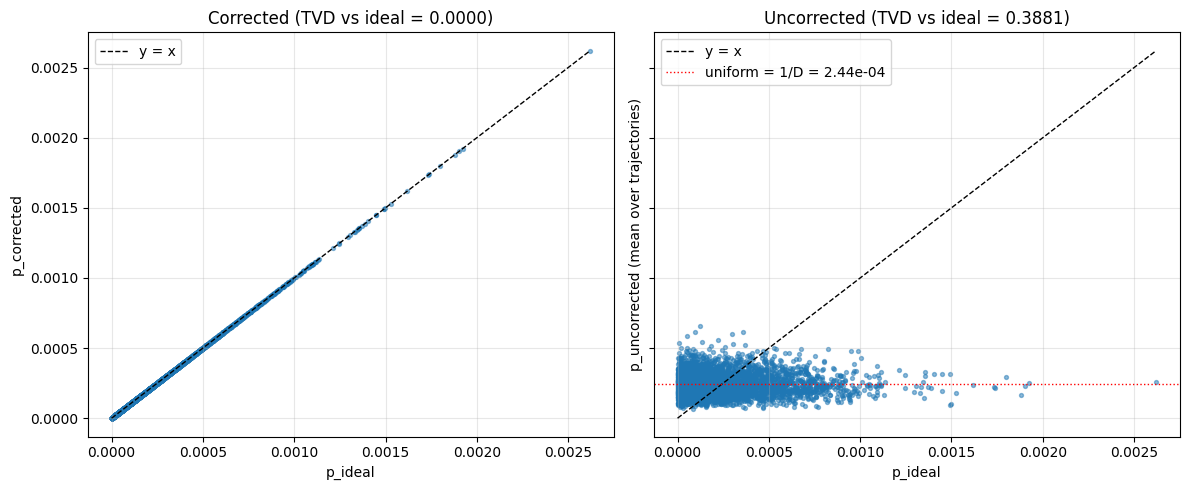

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(p_ideal, p_corrected, s=8, alpha=0.5)
axes[0].plot([0, p_ideal.max()], [0, p_ideal.max()], 'k--', lw=1, label='y = x')
axes[0].set_xlabel('p_ideal')
axes[0].set_ylabel('p_corrected')
axes[0].set_title(f'Corrected (TVD vs ideal = {tvd_corr_vs_ideal:.4f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(p_ideal, p_uncorrected, s=8, alpha=0.5)
axes[1].plot([0, p_ideal.max()], [0, p_ideal.max()], 'k--', lw=1, label='y = x')
axes[1].axhline(1.0 / DIM, color='r', ls=':', lw=1, label=f'uniform = 1/D = {1.0/DIM:.2e}')
axes[1].set_xlabel('p_ideal')
axes[1].set_ylabel('p_uncorrected (mean over trajectories)')
axes[1].set_title(f'Uncorrected (TVD vs ideal = {tvd_uncorr_vs_ideal:.4f})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Sorted distribution

Bitstrings sorted by `p_ideal` descending. Lets you see the shape of all
three distributions overlaid: where the corrected line tracks the ideal
exactly, and where the uncorrected line diverges.

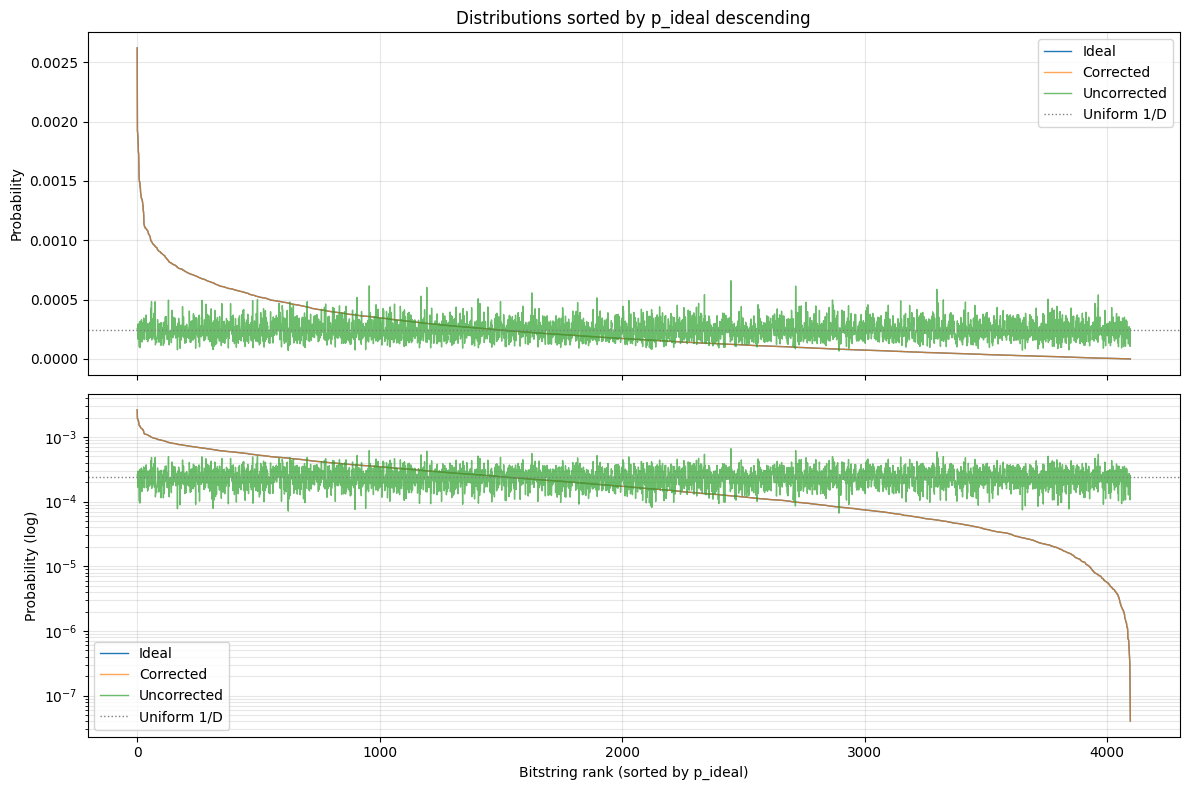

In [20]:
order = np.argsort(-p_ideal)
x = np.arange(DIM)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Linear-scale overlay
axes[0].plot(x, p_ideal[order],       label='Ideal',       lw=1.0)
axes[0].plot(x, p_corrected[order],   label='Corrected',   lw=1.0, alpha=0.7)
axes[0].plot(x, p_uncorrected[order], label='Uncorrected', lw=1.0, alpha=0.7)
axes[0].axhline(1.0 / DIM, color='gray', ls=':', lw=1, label='Uniform 1/D')
axes[0].set_ylabel('Probability')
axes[0].set_title('Distributions sorted by p_ideal descending')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Log-scale
axes[1].semilogy(x, p_ideal[order],       label='Ideal',       lw=1.0)
axes[1].semilogy(x, p_corrected[order],   label='Corrected',   lw=1.0, alpha=0.7)
axes[1].semilogy(x, p_uncorrected[order], label='Uncorrected', lw=1.0, alpha=0.7)
axes[1].axhline(1.0 / DIM, color='gray', ls=':', lw=1, label='Uniform 1/D')
axes[1].set_xlabel('Bitstring rank (sorted by p_ideal)')
axes[1].set_ylabel('Probability (log)')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 10. Per-bitstring probability changes

Two views of how individual bitstrings shift:

- **Histogram of differences**: $p_\mathrm{observed}(x) - p_\mathrm{ideal}(x)$
  across all $D$ bitstrings. A delta function at 0 means perfect agreement.
  A wide distribution centered at 0 means structured disagreement.
- **Top-20 ideal bitstrings**: show their $p_\mathrm{ideal}$, $p_\mathrm{corrected}$,
  and $p_\mathrm{uncorrected}$ side by side. These are the bitstrings that
  matter most for XEB (high-ideal-probability strings dominate the score).

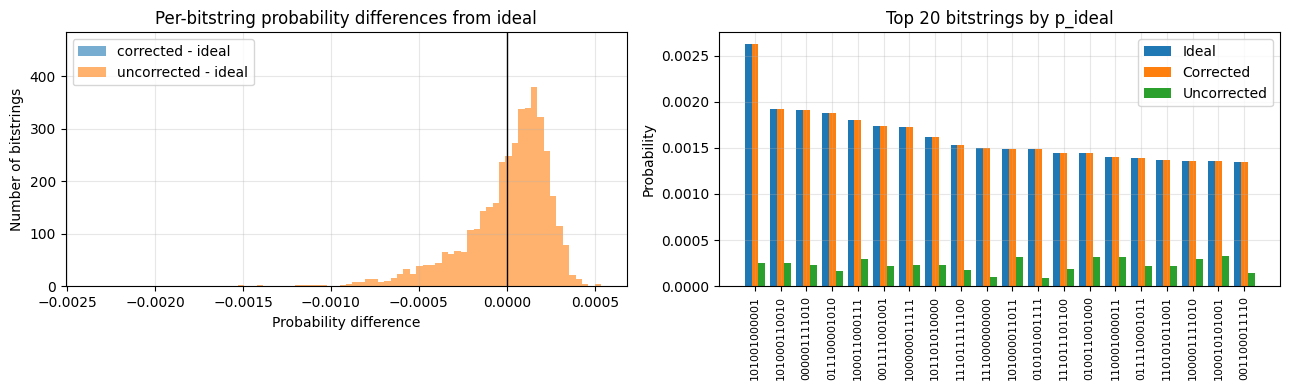

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(p_corrected - p_ideal, bins=80, alpha=0.6, label='corrected - ideal')
axes[0].hist(p_uncorrected - p_ideal, bins=80, alpha=0.6, label='uncorrected - ideal')
axes[0].axvline(0, color='k', lw=1)
axes[0].set_xlabel('Probability difference')
axes[0].set_ylabel('Number of bitstrings')
axes[0].set_title('Per-bitstring probability differences from ideal')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Top 20 by ideal probability
top_n   = 20
top_idx = np.argsort(-p_ideal)[:top_n]
labels  = [format(i, f'0{N_LOGICAL}b')[::-1] for i in top_idx]  # Google order
xpos    = np.arange(top_n)
width   = 0.27

axes[1].bar(xpos - width, p_ideal[top_idx],       width, label='Ideal')
axes[1].bar(xpos,         p_corrected[top_idx],   width, label='Corrected')
axes[1].bar(xpos + width, p_uncorrected[top_idx], width, label='Uncorrected')
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(labels, rotation=90, fontsize=8)
axes[1].set_ylabel('Probability')
axes[1].set_title(f'Top {top_n} bitstrings by p_ideal')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Per-trajectory variation in the uncorrected case

A diagnostic: how much do individual uncorrected trajectories agree with the
ideal? Spread tells you whether the random Paulis cluster around a few
specific outcomes or sample broadly across the Pauli group.

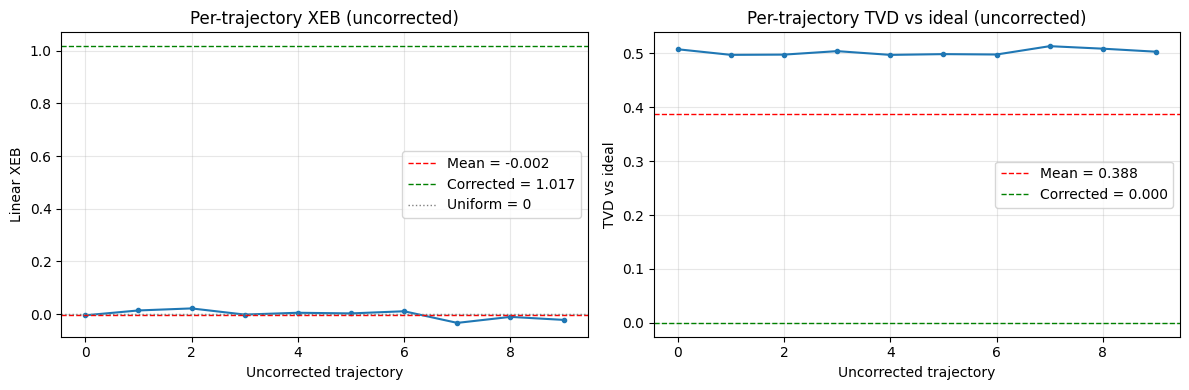

In [22]:
per_traj_xeb = [xeb_linear(p_ideal, p) for p in per_traj_uncorrected]
per_traj_tvd = [tvd(p, p_ideal)        for p in per_traj_uncorrected]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(per_traj_xeb, marker='o', ms=3)
axes[0].axhline(xeb_uncorr, color='r', ls='--', lw=1, label=f'Mean = {xeb_uncorr:.3f}')
axes[0].axhline(xeb_corr,   color='g', ls='--', lw=1, label=f'Corrected = {xeb_corr:.3f}')
axes[0].axhline(0,          color='gray', ls=':', lw=1, label='Uniform = 0')
axes[0].set_xlabel('Uncorrected trajectory')
axes[0].set_ylabel('Linear XEB')
axes[0].set_title('Per-trajectory XEB (uncorrected)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(per_traj_tvd, marker='o', ms=3)
axes[1].axhline(tvd_uncorr_vs_ideal, color='r', ls='--', lw=1, label=f'Mean = {tvd_uncorr_vs_ideal:.3f}')
axes[1].axhline(tvd_corr_vs_ideal,   color='g', ls='--', lw=1, label=f'Corrected = {tvd_corr_vs_ideal:.3f}')
axes[1].set_xlabel('Uncorrected trajectory')
axes[1].set_ylabel('TVD vs ideal')
axes[1].set_title('Per-trajectory TVD vs ideal (uncorrected)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. How to read the results

After running, look at three things together:

1. **TVD(uncorrected, uniform) vs TVD(uncorrected, ideal).** Whichever is
   smaller tells you whether the uncorrected output is closer to pure noise
   or closer to the ideal structure. If they're comparable, it's "structured
   noise" — neither fully random nor recognizably ideal.
2. **Scatter plot shape for the uncorrected case.** Diagonal cloud =
   diagonal-with-noise; flat horizontal cloud near $1/D$ = uniform;
   anti-diagonal or scattered = different structure entirely.
3. **XEB gap between corrected and uncorrected.** This is your headline
   LCED-style number for the Pauli-frame question, computed at the level
   of corrections-on vs corrections-off rather than MBQC vs unitary.

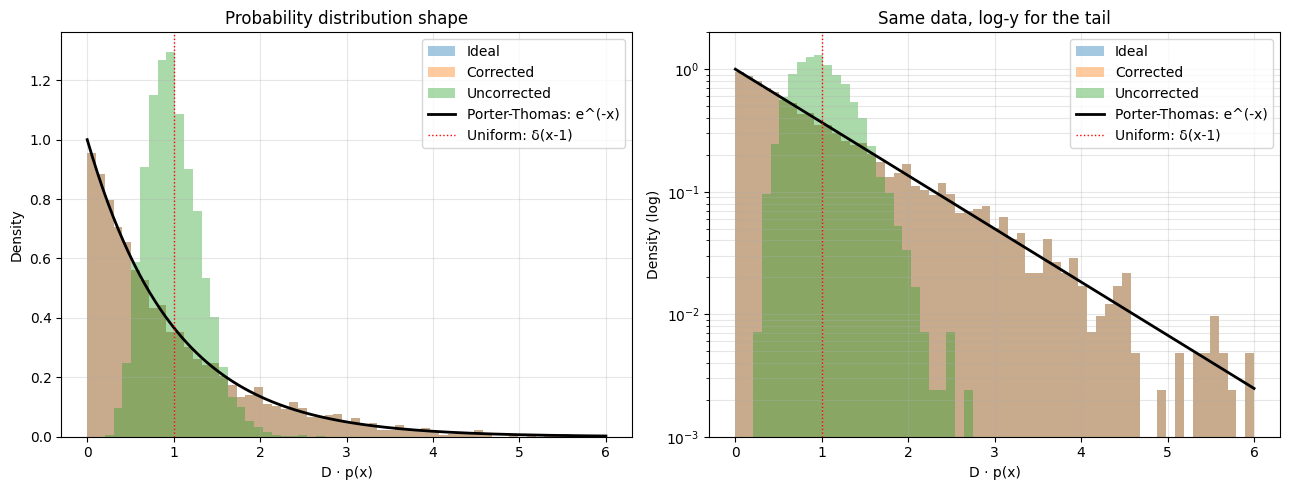

Mean of D · p (should be 1 for any normalized distribution):
  Ideal:       1.0000
  Corrected:   1.0000
  Uncorrected: 1.0000

Variance of D · p (Porter-Thomas = 1, uniform = 0):
  Ideal:       1.0175
  Corrected:   1.0175
  Uncorrected: 0.1019


In [23]:
# Porter-Thomas test: histogram of D * p(x) should follow Exp(1) for a
# Porter-Thomas distributed sampler.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bin edges: dense near 0, capped at 6 (Exp(1) has 99.75% mass below 6)
bins = np.linspace(0, 6, 60)
x_theory = np.linspace(0, 6, 200)
pt_pdf = np.exp(-x_theory)

# Left: linear scale
axes[0].hist(DIM * p_ideal,       bins=bins, density=True, alpha=0.4,
             label='Ideal',         color='C0')
axes[0].hist(DIM * p_corrected,   bins=bins, density=True, alpha=0.4,
             label='Corrected',     color='C1')
axes[0].hist(DIM * p_uncorrected, bins=bins, density=True, alpha=0.4,
             label='Uncorrected',   color='C2')
axes[0].plot(x_theory, pt_pdf, 'k-', lw=2, label='Porter-Thomas: e^(-x)')
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Uniform: δ(x-1)')
axes[0].set_xlabel('D · p(x)')
axes[0].set_ylabel('Density')
axes[0].set_title('Probability distribution shape')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: log y-scale to see the exponential tail
axes[1].hist(DIM * p_ideal,       bins=bins, density=True, alpha=0.4,
             label='Ideal',         color='C0')
axes[1].hist(DIM * p_corrected,   bins=bins, density=True, alpha=0.4,
             label='Corrected',     color='C1')
axes[1].hist(DIM * p_uncorrected, bins=bins, density=True, alpha=0.4,
             label='Uncorrected',   color='C2')
axes[1].plot(x_theory, pt_pdf, 'k-', lw=2, label='Porter-Thomas: e^(-x)')
axes[1].axvline(1.0, color='red', ls=':', lw=1, label='Uniform: δ(x-1)')
axes[1].set_yscale('log')
axes[1].set_ylim(1e-3, 2)
axes[1].set_xlabel('D · p(x)')
axes[1].set_ylabel('Density (log)')
axes[1].set_title('Same data, log-y for the tail')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Print sufficient statistics
print(f'Mean of D · p (should be 1 for any normalized distribution):')
print(f'  Ideal:       {np.mean(DIM * p_ideal):.4f}')
print(f'  Corrected:   {np.mean(DIM * p_corrected):.4f}')
print(f'  Uncorrected: {np.mean(DIM * p_uncorrected):.4f}')
print()
print(f'Variance of D · p (Porter-Thomas = 1, uniform = 0):')
print(f'  Ideal:       {np.var(DIM * p_ideal):.4f}')
print(f'  Corrected:   {np.var(DIM * p_corrected):.4f}')
print(f'  Uncorrected: {np.var(DIM * p_uncorrected):.4f}')

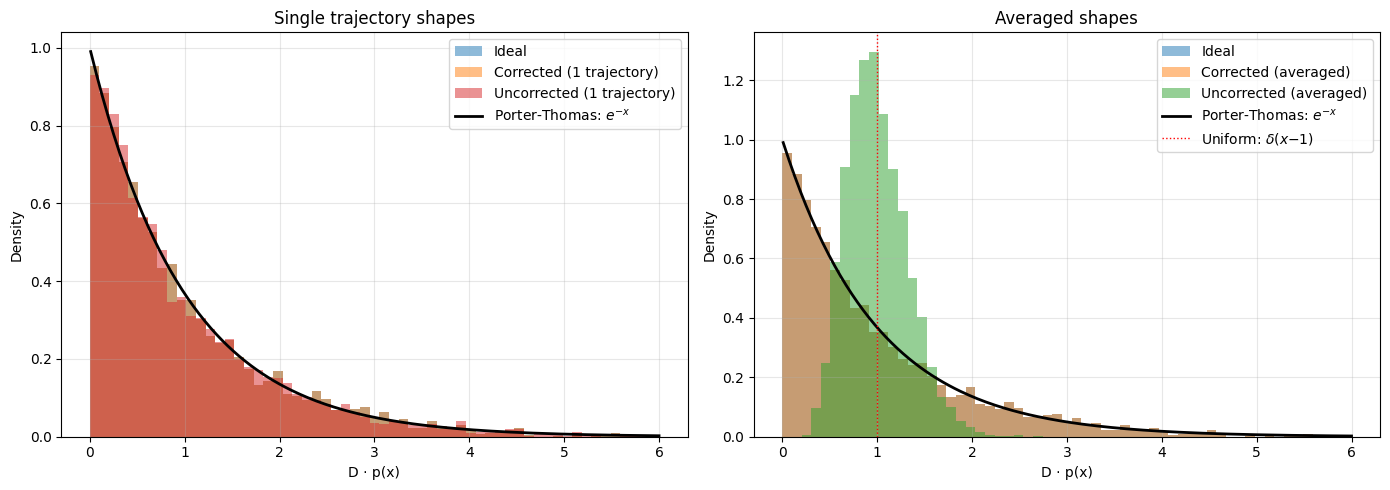

Variance of D · p(x)   (Porter-Thomas = 1.0, Uniform = 0.0):
  Ideal:                       1.0175
  Single corrected trajectory: 1.0175
  Single uncorrected trajectory: 1.0171
  Averaged corrected:          1.0175
  Averaged uncorrected:        0.1019
  Best-fit Exp(λ) rate for Ideal: λ = 1.016  (Porter-Thomas: λ = 1)
  Best-fit Exp(λ) rate for Single uncorrected: λ = 1.022  (Porter-Thomas: λ = 1)
  Best-fit Exp(λ) rate for Averaged uncorrected: λ = 0.589  (Porter-Thomas: λ = 1)


In [24]:
from scipy.optimize import curve_fit

# Pick one uncorrected trajectory and one corrected trajectory
single_uncorr = per_traj_uncorrected[0]
single_corr   = per_traj_corrected[0]

dpi_ideal     = DIM * p_ideal
dpi_corr_avg  = DIM * p_corrected
dpi_uncor_avg = DIM * p_uncorrected
dpi_uncor_one = DIM * single_uncorr
dpi_corr_one  = DIM * single_corr

bins = np.linspace(0, 6, 60)
x_th = np.linspace(0.01, 6, 200)
pt_pdf = np.exp(-x_th)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: single trajectories vs ideal vs Porter-Thomas
axes[0].hist(dpi_ideal,     bins=bins, density=True, alpha=0.5,
             label='Ideal',                              color='C0')
axes[0].hist(dpi_corr_one,  bins=bins, density=True, alpha=0.5,
             label='Corrected (1 trajectory)',           color='C1')
axes[0].hist(dpi_uncor_one, bins=bins, density=True, alpha=0.5,
             label='Uncorrected (1 trajectory)',         color='C3')
axes[0].plot(x_th, pt_pdf, 'k-', lw=2,
             label='Porter-Thomas: $e^{-x}$')
axes[0].set_xlabel('D · p(x)')
axes[0].set_ylabel('Density')
axes[0].set_title('Single trajectory shapes')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: averaged distributions
axes[1].hist(dpi_ideal,     bins=bins, density=True, alpha=0.5,
             label='Ideal',                              color='C0')
axes[1].hist(dpi_corr_avg,  bins=bins, density=True, alpha=0.5,
             label='Corrected (averaged)',               color='C1')
axes[1].hist(dpi_uncor_avg, bins=bins, density=True, alpha=0.5,
             label='Uncorrected (averaged)',             color='C2')
axes[1].plot(x_th, pt_pdf, 'k-', lw=2,
             label='Porter-Thomas: $e^{-x}$')
axes[1].axvline(1.0, color='red', ls=':', lw=1, label='Uniform: $\\delta(x{-}1)$')
axes[1].set_xlabel('D · p(x)')
axes[1].set_ylabel('Density')
axes[1].set_title('Averaged shapes')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Sufficient statistic: variance of D*p
# (Porter-Thomas = 1, Uniform = 0, anything in between is partial)
print('Variance of D · p(x)   (Porter-Thomas = 1.0, Uniform = 0.0):')
print(f'  Ideal:                       {np.var(dpi_ideal):.4f}')
print(f'  Single corrected trajectory: {np.var(dpi_corr_one):.4f}')
print(f'  Single uncorrected trajectory: {np.var(dpi_uncor_one):.4f}')
print(f'  Averaged corrected:          {np.var(dpi_corr_avg):.4f}')
print(f'  Averaged uncorrected:        {np.var(dpi_uncor_avg):.4f}')

# Optional: fit an exponential rate to the binned histogram
def exp_pdf(x, lam):
    return lam * np.exp(-lam * x)

for label, data in [
    ('Ideal',                  dpi_ideal),
    ('Single uncorrected',     dpi_uncor_one),
    ('Averaged uncorrected',   dpi_uncor_avg),
]:
    hist, edges = np.histogram(data, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    try:
        popt, _ = curve_fit(exp_pdf, centers, hist, p0=[1.0])
        print(f'  Best-fit Exp(λ) rate for {label}: λ = {popt[0]:.3f}  '
              f'(Porter-Thomas: λ = 1)')
    except RuntimeError:
        print(f'  Fit failed for {label}')

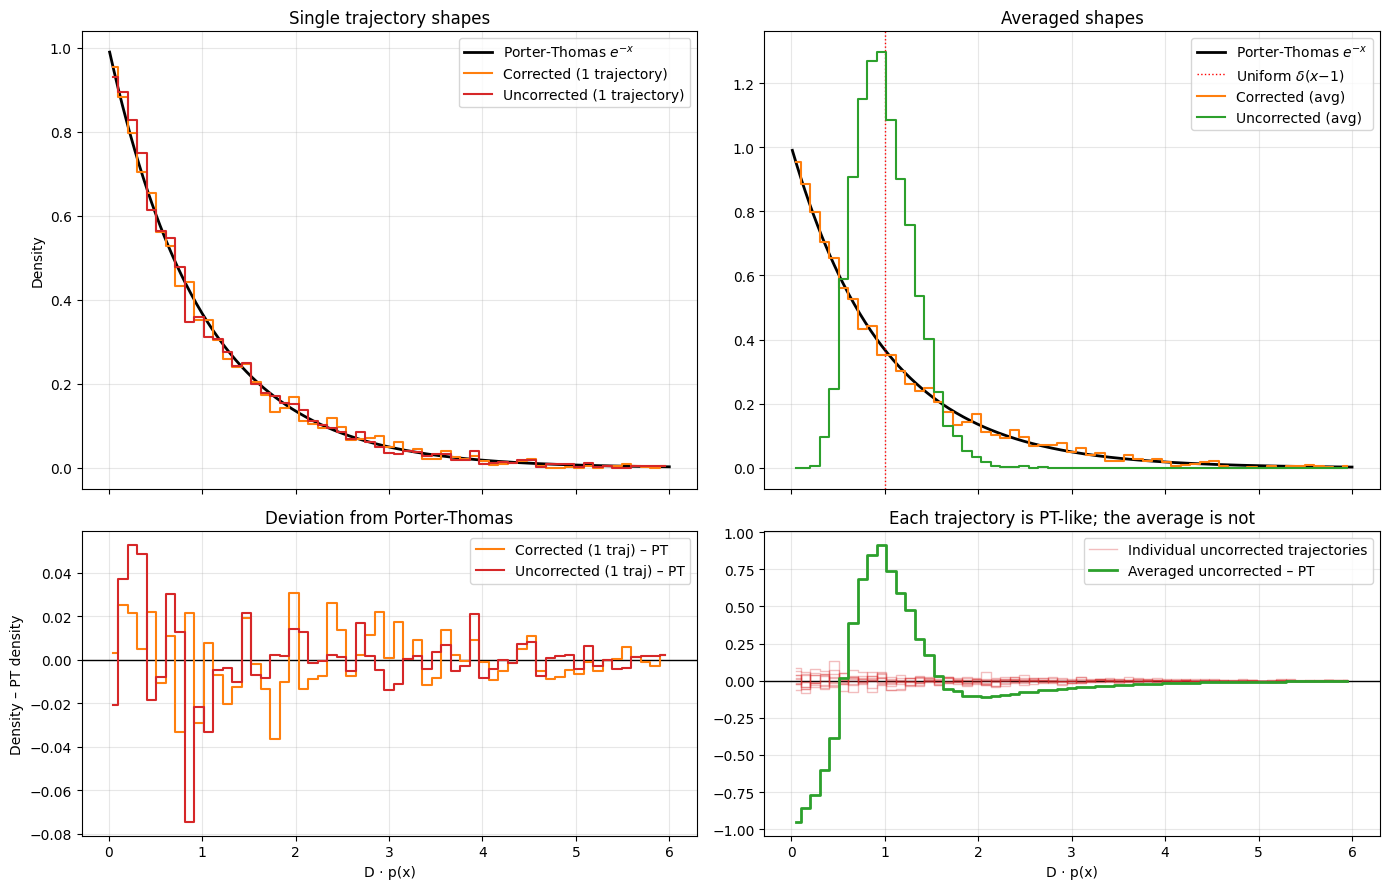

Variance of D · p(x)   (Porter-Thomas = 1.0, Uniform = 0.0):
  Ideal:                         1.0175
  Single corrected trajectory:   1.0175
  Single uncorrected trajectory: 1.0171
  Averaged corrected:            1.0175
  Averaged uncorrected:          0.1019


In [26]:
from scipy.optimize import curve_fit

# Reuse your existing D·p arrays
dpi_ideal     = DIM * p_ideal
dpi_corr_one  = DIM * per_traj_corrected[0]
dpi_uncor_one = DIM * per_traj_uncorrected[0]
dpi_corr_avg  = DIM * p_corrected
dpi_uncor_avg = DIM * p_uncorrected

bins    = np.linspace(0, 6, 60)
centers = 0.5 * (bins[:-1] + bins[1:])
x_th    = np.linspace(0.01, 6, 400)
pt_pdf  = np.exp(-x_th)
pt_at_centers = np.exp(-centers)


def density_hist(data):
    h, _ = np.histogram(data, bins=bins, density=True)
    return h


h_corr_one  = density_hist(dpi_corr_one)
h_uncor_one = density_hist(dpi_uncor_one)
h_corr_avg  = density_hist(dpi_corr_avg)
h_uncor_avg = density_hist(dpi_uncor_avg)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2]})

# --- Top row: histograms as step lines ---

axes[0, 0].plot(x_th, pt_pdf, 'k-', lw=2, label='Porter-Thomas $e^{-x}$')
axes[0, 0].step(centers, h_corr_one,  where='mid', color='C1', lw=1.5,
                label='Corrected (1 trajectory)')
axes[0, 0].step(centers, h_uncor_one, where='mid', color='C3', lw=1.5,
                label='Uncorrected (1 trajectory)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Single trajectory shapes')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(x_th, pt_pdf, 'k-', lw=2, label='Porter-Thomas $e^{-x}$')
axes[0, 1].axvline(1.0, color='red', ls=':', lw=1, label='Uniform $\\delta(x{-}1)$')
axes[0, 1].step(centers, h_corr_avg,  where='mid', color='C1', lw=1.5,
                label='Corrected (avg)')
axes[0, 1].step(centers, h_uncor_avg, where='mid', color='C2', lw=1.5,
                label='Uncorrected (avg)')
axes[0, 1].set_title('Averaged shapes')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# --- Bottom row: difference from Porter-Thomas ---

axes[1, 0].axhline(0, color='k', lw=1)
axes[1, 0].step(centers, h_corr_one  - pt_at_centers, where='mid', color='C1',
                lw=1.5, label='Corrected (1 traj) – PT')
axes[1, 0].step(centers, h_uncor_one - pt_at_centers, where='mid', color='C3',
                lw=1.5, label='Uncorrected (1 traj) – PT')
axes[1, 0].set_xlabel('D · p(x)')
axes[1, 0].set_ylabel('Density – PT density')
axes[1, 0].set_title('Deviation from Porter-Thomas')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Replace the bottom-right panel with: all 10 individual uncorrected trajectories,
# faint, plus the average, overlaid on Porter-Thomas.

axes[1, 1].axhline(0, color='k', lw=1)
for k, p_traj in enumerate(per_traj_uncorrected):
    h_k = density_hist(DIM * p_traj)
    axes[1, 1].step(centers, h_k - pt_at_centers, where='mid',
                    color='C3', alpha=0.3, lw=1,
                    label='Individual uncorrected trajectories' if k == 0 else None)
axes[1, 1].step(centers, h_uncor_avg - pt_at_centers, where='mid',
                color='C2', lw=2, label='Averaged uncorrected – PT')
axes[1, 1].set_xlabel('D · p(x)')
axes[1, 1].set_title('Each trajectory is PT-like; the average is not')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Variance of D · p(x)   (Porter-Thomas = 1.0, Uniform = 0.0):')
print(f'  Ideal:                         {np.var(dpi_ideal):.4f}')
print(f'  Single corrected trajectory:   {np.var(dpi_corr_one):.4f}')
print(f'  Single uncorrected trajectory: {np.var(dpi_uncor_one):.4f}')
print(f'  Averaged corrected:            {np.var(dpi_corr_avg):.4f}')
print(f'  Averaged uncorrected:          {np.var(dpi_uncor_avg):.4f}')

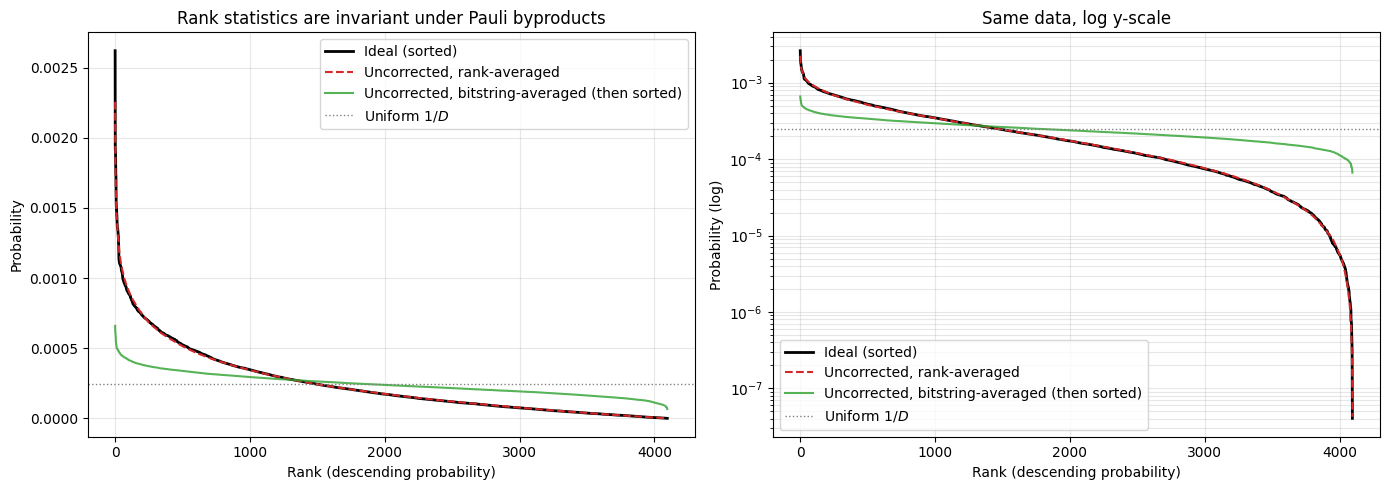

Rank-averaged uncorrected vs sorted ideal:
  Max  abs difference: 3.65e-04
  Mean abs difference: 3.56e-06
  (small means rank statistics are preserved — Pauli byproducts permute labels, not values)


In [27]:
# Rank-sorted statistics: average each trajectory's sorted probabilities
# rank-by-rank instead of bitstring-by-bitstring. Sorting strips the random
# Pauli permutation, so this should recover the ideal sorted distribution.

sorted_ideal     = np.sort(p_ideal)[::-1]
sorted_per_traj  = np.sort(per_traj_uncorrected, axis=1)[:, ::-1]
sorted_rank_avg  = sorted_per_traj.mean(axis=0)
sorted_bitstring = np.sort(p_uncorrected)[::-1]   # for contrast

x = np.arange(DIM)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, sorted_ideal,     'k-',  lw=2,
             label='Ideal (sorted)')
axes[0].plot(x, sorted_rank_avg,  'C3--', lw=1.5,
             label='Uncorrected, rank-averaged')
axes[0].plot(x, sorted_bitstring, 'C2-',  lw=1.5, alpha=0.8,
             label='Uncorrected, bitstring-averaged (then sorted)')
axes[0].axhline(1 / DIM, color='gray', ls=':', lw=1, label='Uniform $1/D$')
axes[0].set_xlabel('Rank (descending probability)')
axes[0].set_ylabel('Probability')
axes[0].set_title('Rank statistics are invariant under Pauli byproducts')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].semilogy(x, sorted_ideal,     'k-',  lw=2,
                 label='Ideal (sorted)')
axes[1].semilogy(x, sorted_rank_avg,  'C3--', lw=1.5,
                 label='Uncorrected, rank-averaged')
axes[1].semilogy(x, sorted_bitstring, 'C2-',  lw=1.5, alpha=0.8,
                 label='Uncorrected, bitstring-averaged (then sorted)')
axes[1].axhline(1 / DIM, color='gray', ls=':', lw=1, label='Uniform $1/D$')
axes[1].set_xlabel('Rank (descending probability)')
axes[1].set_ylabel('Probability (log)')
axes[1].set_title('Same data, log y-scale')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Quantify recovery
max_diff  = np.max( np.abs(sorted_rank_avg - sorted_ideal))
mean_diff = np.mean(np.abs(sorted_rank_avg - sorted_ideal))
print(f'Rank-averaged uncorrected vs sorted ideal:')
print(f'  Max  abs difference: {max_diff :.2e}')
print(f'  Mean abs difference: {mean_diff:.2e}')
print(f'  (small means rank statistics are preserved — Pauli byproducts permute labels, not values)')

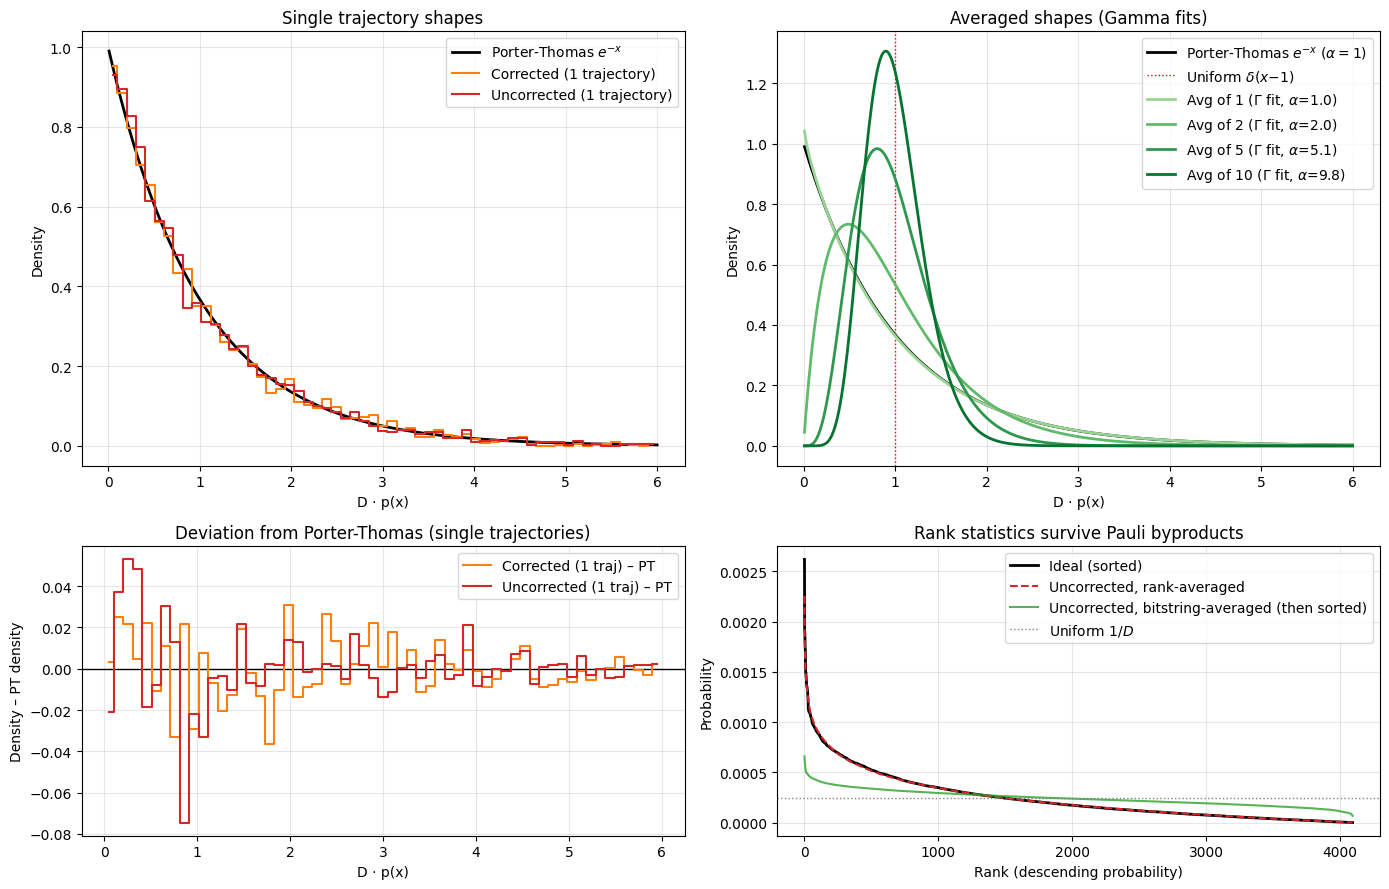

Variance of D · p(x)   (Porter-Thomas = 1.0, Uniform = 0.0):
  Single corrected trajectory:   1.0175
  Single uncorrected trajectory: 1.0171
  Averaged corrected:            1.0175
  Averaged uncorrected:          0.1019

Rank-averaged uncorrected vs sorted ideal:
  Max  abs difference: 3.65e-04
  Mean abs difference: 3.56e-06
Variance of D · p_avg as trajectory count grows:
  k =  1:  Var(D · p) = 1.0171
  k =  2:  Var(D · p) = 0.5108
  k =  5:  Var(D · p) = 0.1966
  k = 10:  Var(D · p) = 0.1019


In [31]:
from scipy.optimize import curve_fit

# --- D·p arrays for histograms ---
dpi_corr_one  = DIM * per_traj_corrected[0]
dpi_uncor_one = DIM * per_traj_uncorrected[0]
dpi_corr_avg  = DIM * p_corrected
dpi_uncor_avg = DIM * p_uncorrected

bins    = np.linspace(0, 6, 60)
centers = 0.5 * (bins[:-1] + bins[1:])
x_th    = np.linspace(0.01, 6, 400)
pt_pdf  = np.exp(-x_th)
pt_at_centers = np.exp(-centers)


def density_hist(data):
    h, _ = np.histogram(data, bins=bins, density=True)
    return h


h_corr_one  = density_hist(dpi_corr_one)
h_uncor_one = density_hist(dpi_uncor_one)
h_corr_avg  = density_hist(dpi_corr_avg)
h_uncor_avg = density_hist(dpi_uncor_avg)

# --- Rank-sorted data for bottom-right panel ---
sorted_ideal     = np.sort(p_ideal)[::-1]
sorted_per_traj  = np.sort(per_traj_uncorrected, axis=1)[:, ::-1]
sorted_rank_avg  = sorted_per_traj.mean(axis=0)
sorted_bitstring = np.sort(p_uncorrected)[::-1]
rank_x = np.arange(DIM)

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9),
                         gridspec_kw={'height_ratios': [3, 2]})

# Top-left: single trajectory shapes
axes[0, 0].plot(x_th, pt_pdf, 'k-', lw=2, label='Porter-Thomas $e^{-x}$')
axes[0, 0].step(centers, h_corr_one,  where='mid', color='C1', lw=1.5,
                label='Corrected (1 trajectory)')
axes[0, 0].step(centers, h_uncor_one, where='mid', color='C3', lw=1.5,
                label='Uncorrected (1 trajectory)')
axes[0, 0].set_xlabel('D · p(x)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Single trajectory shapes')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Top-right: averaged shapes, with progressive trajectory counts
n_traj_total = len(per_traj_uncorrected)
n_steps      = [1, 2, 5, n_traj_total]   # progression of K
colors_avg   = plt.cm.Greens(np.linspace(0.4, 0.85, len(n_steps)))

from scipy import stats

x_smooth = np.linspace(0.01, 6, 400)

axes[0, 1].plot(x_th, pt_pdf, 'k-', lw=2,
                label='Porter-Thomas $e^{-x}$ ($\\alpha=1$)')
axes[0, 1].axvline(1.0, color='red', ls=':', lw=1,
                   label='Uniform $\\delta(x{-}1)$')

for k, color in zip(n_steps, colors_avg):
    p_avg_k  = np.mean(per_traj_uncorrected[:k], axis=0)
    var_k    = np.var(DIM * p_avg_k)
    alpha_k  = 1.0 / var_k if var_k > 0 else np.inf
    pdf_curve = stats.gamma.pdf(x_smooth, a=alpha_k, scale=1.0 / alpha_k)
    axes[0, 1].plot(x_smooth, pdf_curve, color=color, lw=2,
                    label=f'Avg of {k} (Γ fit, $\\alpha$={alpha_k:.1f})')

axes[0, 1].set_xlabel('D · p(x)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Averaged shapes (Gamma fits)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Bottom-left: deviation from Porter-Thomas (single trajectories)
axes[1, 0].axhline(0, color='k', lw=1)
axes[1, 0].step(centers, h_corr_one  - pt_at_centers, where='mid', color='C1',
                lw=1.5, label='Corrected (1 traj) – PT')
axes[1, 0].step(centers, h_uncor_one - pt_at_centers, where='mid', color='C3',
                lw=1.5, label='Uncorrected (1 traj) – PT')
axes[1, 0].set_xlabel('D · p(x)')
axes[1, 0].set_ylabel('Density – PT density')
axes[1, 0].set_title('Deviation from Porter-Thomas (single trajectories)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Bottom-right: rank-averaged vs bitstring-averaged uncorrected
axes[1, 1].plot(rank_x, sorted_ideal,     'k-',  lw=2,
                label='Ideal (sorted)')
axes[1, 1].plot(rank_x, sorted_rank_avg,  'C3--', lw=1.5,
                label='Uncorrected, rank-averaged')
axes[1, 1].plot(rank_x, sorted_bitstring, 'C2-',  lw=1.5, alpha=0.8,
                label='Uncorrected, bitstring-averaged (then sorted)')
axes[1, 1].axhline(1 / DIM, color='gray', ls=':', lw=1, label='Uniform $1/D$')
axes[1, 1].set_xlabel('Rank (descending probability)')
axes[1, 1].set_ylabel('Probability')
axes[1, 1].set_title('Rank statistics survive Pauli byproducts')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary stats ---
print('Variance of D · p(x)   (Porter-Thomas = 1.0, Uniform = 0.0):')
print(f'  Single corrected trajectory:   {np.var(dpi_corr_one):.4f}')
print(f'  Single uncorrected trajectory: {np.var(dpi_uncor_one):.4f}')
print(f'  Averaged corrected:            {np.var(dpi_corr_avg):.4f}')
print(f'  Averaged uncorrected:          {np.var(dpi_uncor_avg):.4f}')
print()
max_diff  = np.max( np.abs(sorted_rank_avg - sorted_ideal))
mean_diff = np.mean(np.abs(sorted_rank_avg - sorted_ideal))
print(f'Rank-averaged uncorrected vs sorted ideal:')
print(f'  Max  abs difference: {max_diff :.2e}')
print(f'  Mean abs difference: {mean_diff:.2e}')
print('Variance of D · p_avg as trajectory count grows:')
for k in n_steps:
    p_avg_k = np.mean(per_traj_uncorrected[:k], axis=0)
    print(f'  k = {k:2d}:  Var(D · p) = {np.var(DIM * p_avg_k):.4f}')

In [32]:
print(f'{"k":>4} | {"fitted α":>10} | {"theoretical α=k":>16}')
print('-' * 38)
for k in range(1, len(per_traj_uncorrected) + 1):
    p_avg_k = np.mean(per_traj_uncorrected[:k], axis=0)
    var_k   = np.var(DIM * p_avg_k)
    alpha_k = 1.0 / var_k if var_k > 0 else np.inf
    print(f'{k:>4} | {alpha_k:>10.2f} | {k:>16}')

   k |   fitted α |  theoretical α=k
--------------------------------------
   1 |       0.98 |                1
   2 |       1.96 |                2
   3 |       3.02 |                3
   4 |       4.02 |                4
   5 |       5.09 |                5
   6 |       6.02 |                6
   7 |       6.98 |                7
   8 |       7.94 |                8
   9 |       8.80 |                9
  10 |       9.82 |               10
